# 18 — Global decorations: night, distortion and tiles

Three decorations that belong to the whole globe rather than to a data layer: `nightshade` shades the night side
at an instant, `tissot` makes a projection's distortion visible, and `basemap` pulls XYZ tiles in under the map.

By the end you will be able to put the day/night terminator on a map, show how much a projection stretches at
each latitude, and add a tiled basemap.

API: [`Map.nightshade`](../reference/static_map.md), [`Map.tissot`](../reference/static_map.md),
[`Map.basemap`](../reference/static_map.md).

**Setup** — plus `datetime`, which `nightshade` needs.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.dataset import Dataset
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits two levels up: docs/examples -> repo root.
DATA = Path("../../examples/data")

import datetime as dt


## `nightshade` — the terminator at an instant

`nightshade(when)` shades the hemisphere in darkness at a given moment. Pass a timezone-aware `datetime`: the
terminator's position depends on the exact instant, so a naive datetime is an invitation to be an hour out.

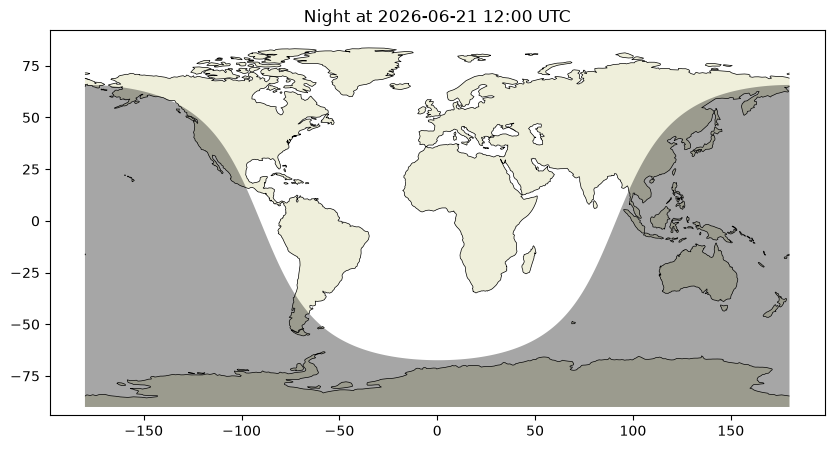

In [2]:
solstice_noon = dt.datetime(2026, 6, 21, 12, 0, tzinfo=dt.timezone.utc)

m = Map(crs=4326, figsize=(10, 5))
m.set_global()
m.coastlines()
m.land()
m.nightshade(solstice_noon)
m.set_title(f"Night at {solstice_noon:%Y-%m-%d %H:%M} UTC")
m.fig;

At the June solstice the terminator tilts hard: the Arctic is in full daylight and night reaches far up over
Antarctica. That tilt *is* the solstice — it is what makes the polar day and polar night. Compare the December
solstice to see it mirror.

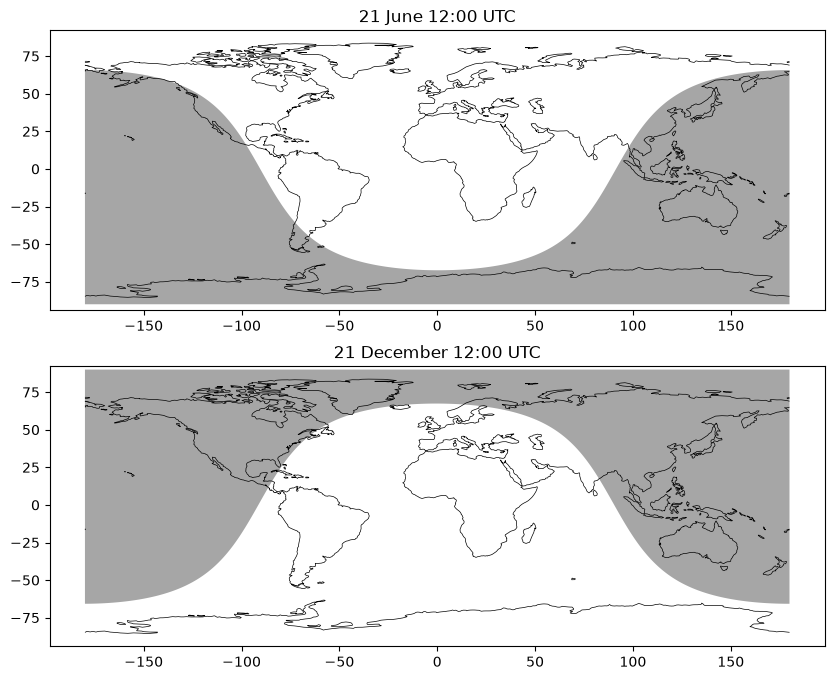

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
for ax, when in zip(axes, (solstice_noon, solstice_noon.replace(month=12, day=21))):
    panel = Map(ax=ax, crs=4326)
    panel.set_global()
    panel.coastlines()
    panel.nightshade(when)
    ax.set_title(f"{when:%d %B} 12:00 UTC")
fig;

The two terminators are mirror images about the equator. `refraction` (default `-0.83°`) sets the sun altitude
counted as sunset — the standard allowance for atmospheric bending — and `n` controls how finely the curve is
sampled.

## `tissot` — making projection distortion visible

Every flat map of a sphere distorts. Tissot's indicatrices make that concrete: circles of **one true ground
radius**, drawn where the projection puts them. Wherever a circle is drawn large, or as an ellipse, the map is
exaggerating at that spot.

| argument | meaning | typical value |
|---|---|---|
| `lons`, `lats` | where to place the circles | sequences of degrees |
| `radius_m` | true ground radius of each circle | `500_000` (500 km) default |
| `n` | points per circle | `64` |

In [4]:
lons = [-150, -90, -30, 30, 90, 150]
lats = [-60, -30, 0, 30, 60]
grid_lons = [lon for lat in lats for lon in lons]
grid_lats = [lat for lat in lats for lon in lons]
print(f"{len(grid_lons)} indicatrices, 800 km radius each")

30 indicatrices, 800 km radius each


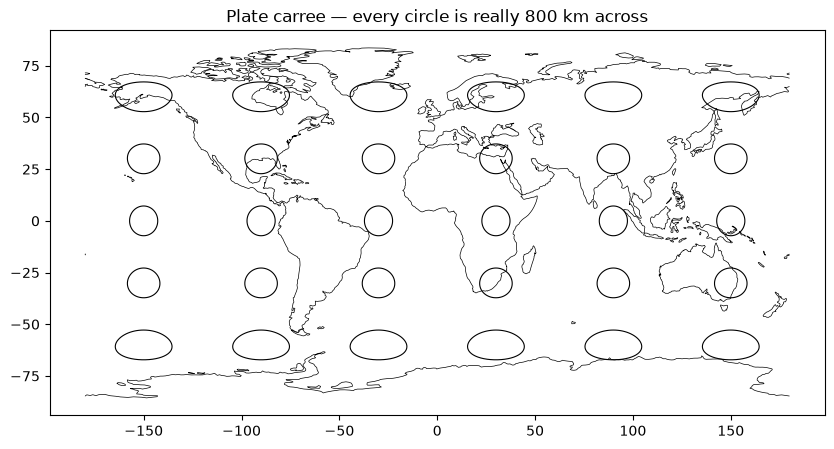

In [5]:
m = Map(crs=4326, figsize=(10, 5))
m.set_global()
m.coastlines()
m.tissot(grid_lons, grid_lats, radius_m=800_000)
m.set_title("Plate carree — every circle is really 800 km across")
m.fig;

In plate carrée the circles stay the same width in degrees but the ground they cover shrinks toward the poles, so
the high-latitude ones are drawn far too large. That is the familiar "Greenland looks enormous" error, measured
rather than asserted.

Put the same circles on an equal-area projection and the distortion moves: areas are preserved, so the circles
keep their size while their *shape* skews.

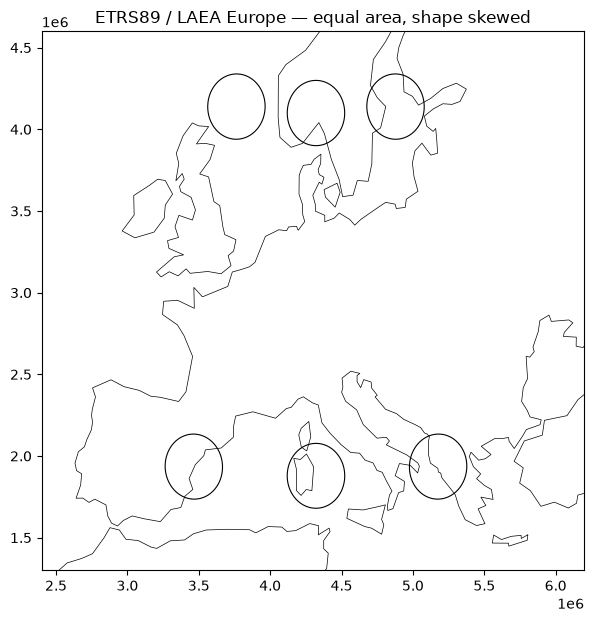

In [6]:
m = Map(crs=3035, figsize=(7, 7))
m.coastlines()
m.tissot([0, 10, 20, 0, 10, 20], [40, 40, 40, 60, 60, 60], radius_m=200_000)
m.set_bounds([2.4e6, 1.3e6, 6.2e6, 4.6e6])   # EPSG:3035 is metres, not degrees
m.set_title("ETRS89 / LAEA Europe — equal area, shape skewed")
m.fig;

This is the trade every projection makes, and `tissot` is the way to see which trade you chose. Reach for it
whenever a map's projection is doing real work — an area comparison, a distance claim — rather than just framing
a picture.

## `basemap` — XYZ tiles under the map

`basemap()` fetches raster tiles and draws them beneath everything else, in the display CRS. **It needs network
access**; offline it is skipped rather than raising, so a notebook stays runnable either way.

Tiles are served in Web Mercator, so EPSG:3857 is the CRS that needs no resampling.

C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


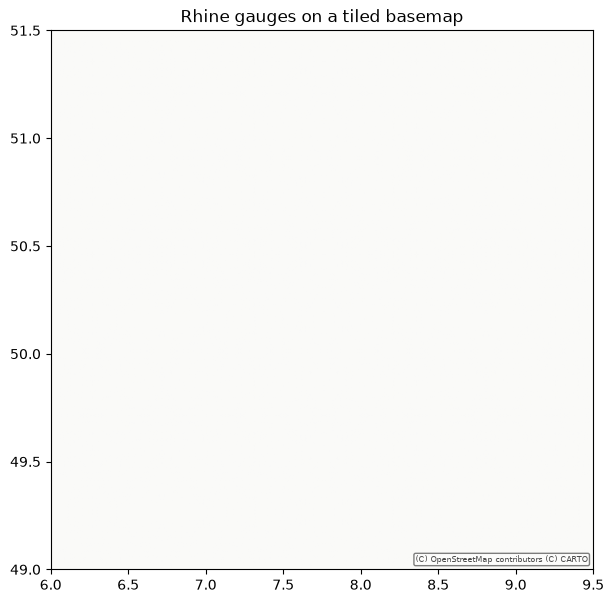

In [7]:
m = Map(crs=3857, figsize=(7, 7))
m.set_bounds([6.0, 49.0, 9.5, 51.5])
m.basemap()
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
m.points(gauges, size=35, cmap="autumn")
m.set_title("Rhine gauges on a tiled basemap")
m.fig;

The gauges now sit on real terrain and settlement rather than on white space, which is what a basemap is for:
context you did not have to source or style yourself. `source=` selects a provider, `api_key=` passes a key for
the keyed ones, and `preset=` takes a provider dictionary.

A caveat worth keeping: tiles are someone else's cartography, at a fixed resolution, under their licence. Check
the attribution terms before publishing, and do not zoom past the level the provider actually serves.

## Takeaway

- `nightshade(when)` shades the night hemisphere; pass a **timezone-aware** datetime.
- `tissot(lons, lats, radius_m=...)` draws equal-ground-radius circles, turning projection distortion from an
  assertion into a measurement.
- `basemap()` adds XYZ tiles underneath, best in EPSG:3857, and is skipped offline rather than failing.
- All three decorate the globe rather than the data, so they belong under `set_global()` or an explicit framing.

That closes the static backend's scene-level tour. The per-plot-type gallery is under
[`plots/`](plots/01_imshow.ipynb).